In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:

!cp -r "/content/drive/MyDrive/KLTN_hand_gesture L2/dataset_1000" "/content/dataset_1000"

!cp "/content/drive/MyDrive/KLTN_hand_gesture L2/gesture.yaml" "/content/gesture.yaml"


In [4]:
%%writefile /content/gesture.yaml
path: /content

train: dataset_1000/images/train
val: dataset_1000/images/val
test: dataset_1000/images/test

names:
  0: call
  1: fist
  2: palm
  3: peace
  4: stop
  5: like


Overwriting /content/gesture.yaml


In [5]:
!pip install -q ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 43.9 MB/s eta 0:00:00


In [6]:
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/KLTN_hand_gesture L2/runs/gesture_v2_1000img/weights/best.pt"

model = YOLO(MODEL_PATH)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [7]:
results = model.train(
    data="/content/gesture.yaml",
    epochs=40,
    imgsz=640,
    batch=16,
    workers=2,
    cache=False,
    project="/content/drive/MyDrive/KLTN_hand_gesture L2/runs",
    name="gesture_v2_L2"
)


Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/gesture.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/KLTN_hand_gesture L2/runs/gesture_v2_1000img/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=gesture_v2_L2, nbs=64, nms=False, opset=None, optimize=False, optimizer=

In [8]:
from pathlib import Path
from ultralytics import YOLO
from IPython.display import Image, display

# Thư mục chính trên Drive
BASE_DIR = Path("/content/drive/MyDrive/KLTN_hand_gesture L2")
RUN_NAME = "gesture_v2_L2"

RUN_DIR = BASE_DIR / "runs" / RUN_NAME         # runs/gesture_v2_L2
DATA_YAML = Path("/content/gesture.yaml")      # yaml đã dùng để train
MODEL_PATH = RUN_DIR / "weights" / "best.pt"   # best.pt sau L2

print("BASE_DIR :", BASE_DIR)
print("RUN_DIR  :", RUN_DIR)
print("MODEL    :", MODEL_PATH)

# Load model cuối cùng
model = YOLO(str(MODEL_PATH))


BASE_DIR : /content/drive/MyDrive/KLTN_hand_gesture L2
RUN_DIR  : /content/drive/MyDrive/KLTN_hand_gesture L2/runs/gesture_v2_L2
MODEL    : /content/drive/MyDrive/KLTN_hand_gesture L2/runs/gesture_v2_L2/weights/best.pt


results.png: /content/drive/MyDrive/KLTN_hand_gesture L2/runs/gesture_v2_L2/results.png


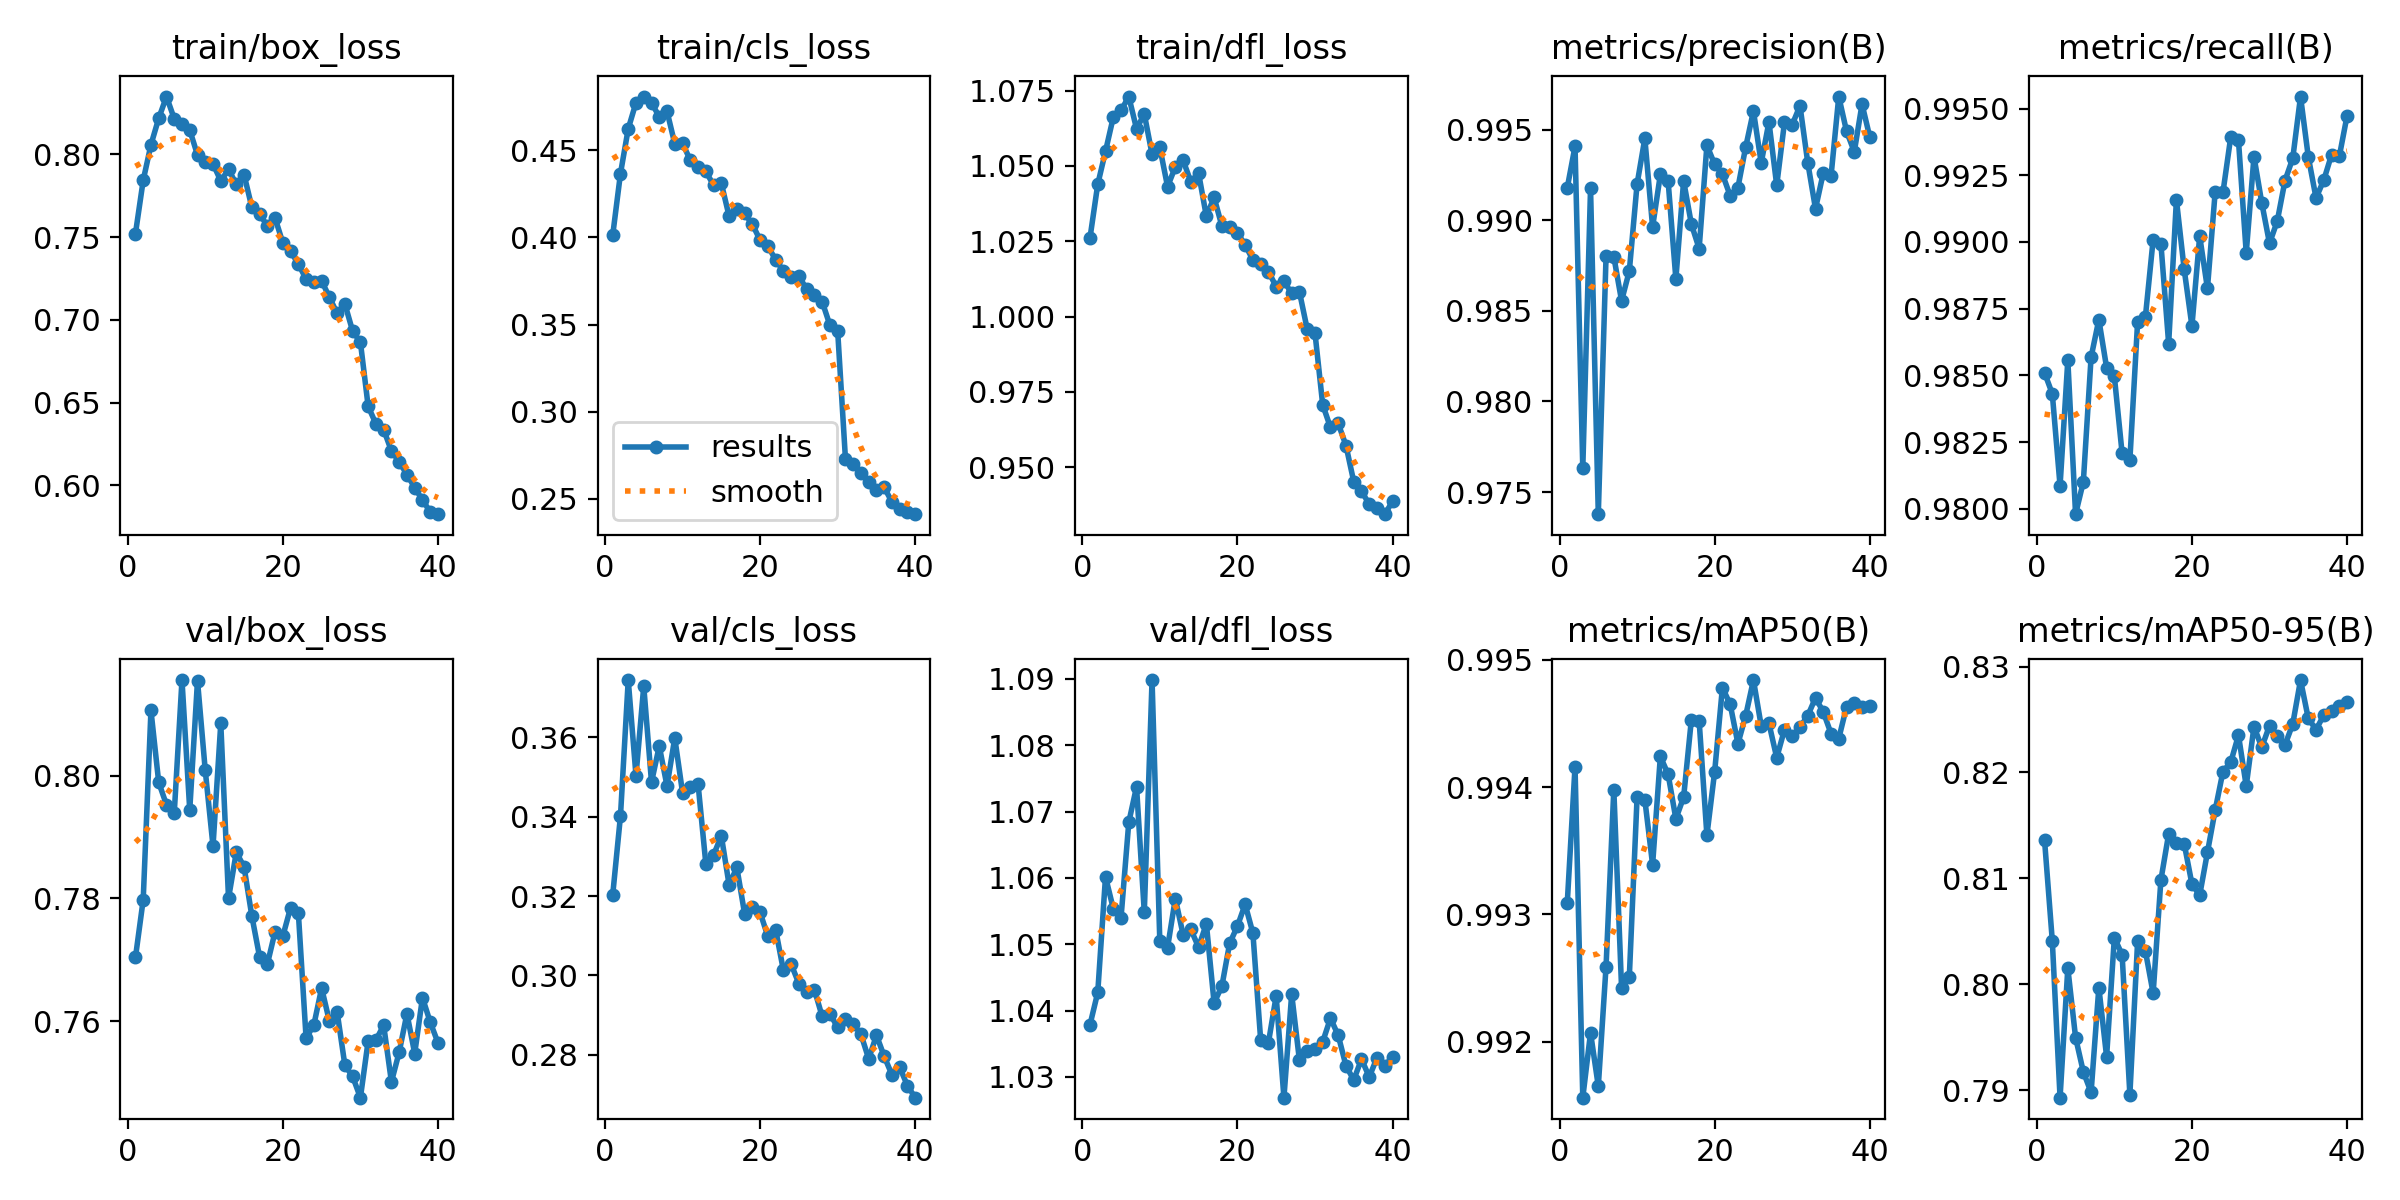

In [9]:
results_png = RUN_DIR / "results.png"
print("results.png:", results_png)

if results_png.exists():
    display(Image(filename=str(results_png)))
else:
    print("❌ Không tìm thấy results.png – kiểm tra lại RUN_NAME / đường dẫn.")


In [10]:
VAL_NAME = RUN_NAME + "_val"   # gesture_v2_L2_val

val_metrics = model.val(
    data=str(DATA_YAML),
    split="val",
    imgsz=640,
    batch=16,
    plots=True,                         # vẽ PR, Confusion Matrix...
    project=str(BASE_DIR / "runs"),
    name=VAL_NAME
)

box_metrics = val_metrics.box
speed = val_metrics.speed

print("=== VAL METRICS ===")
print(f"mAP50-95 (mAP): {box_metrics.map:.4f}")
print(f"mAP50:          {box_metrics.map50:.4f}")
print(f"Precision (P):  {box_metrics.p.mean():.4f}")
print(f"Recall (R):     {box_metrics.r.mean():.4f}")
print(f"F1-score:       {box_metrics.f1.mean():.4f}")

inf_ms = speed['inference']      # ms / ảnh
fps = 1000.0 / inf_ms
print(f"Inference time: {inf_ms:.2f} ms/image  →  FPS ≈ {fps:.2f}")


Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12m summary (fused): 169 layers, 20,109,538 parameters, 0 gradients, 67.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2548.9±745.8 MB/s, size: 1462.2 KB)
val: Scanning /content/dataset_1000/labels/val.cache... 1197 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1197/1197 2.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 75/75 1.7it/s 43.4s
                   all       1197       1197      0.994      0.993      0.995      0.828
                  call        198        198      0.983       0.99      0.994      0.768
                  fist        200        200          1      0.997      0.995      0.772
                  palm        199        199      0.998      0.995      0.995       0.89
                 peace        200        200      0.996      0.995      0.995      0.845
                  stop        200  

Confusion matrix path: /content/drive/MyDrive/KLTN_hand_gesture L2/runs/gesture_v2_L2_val/confusion_matrix.png


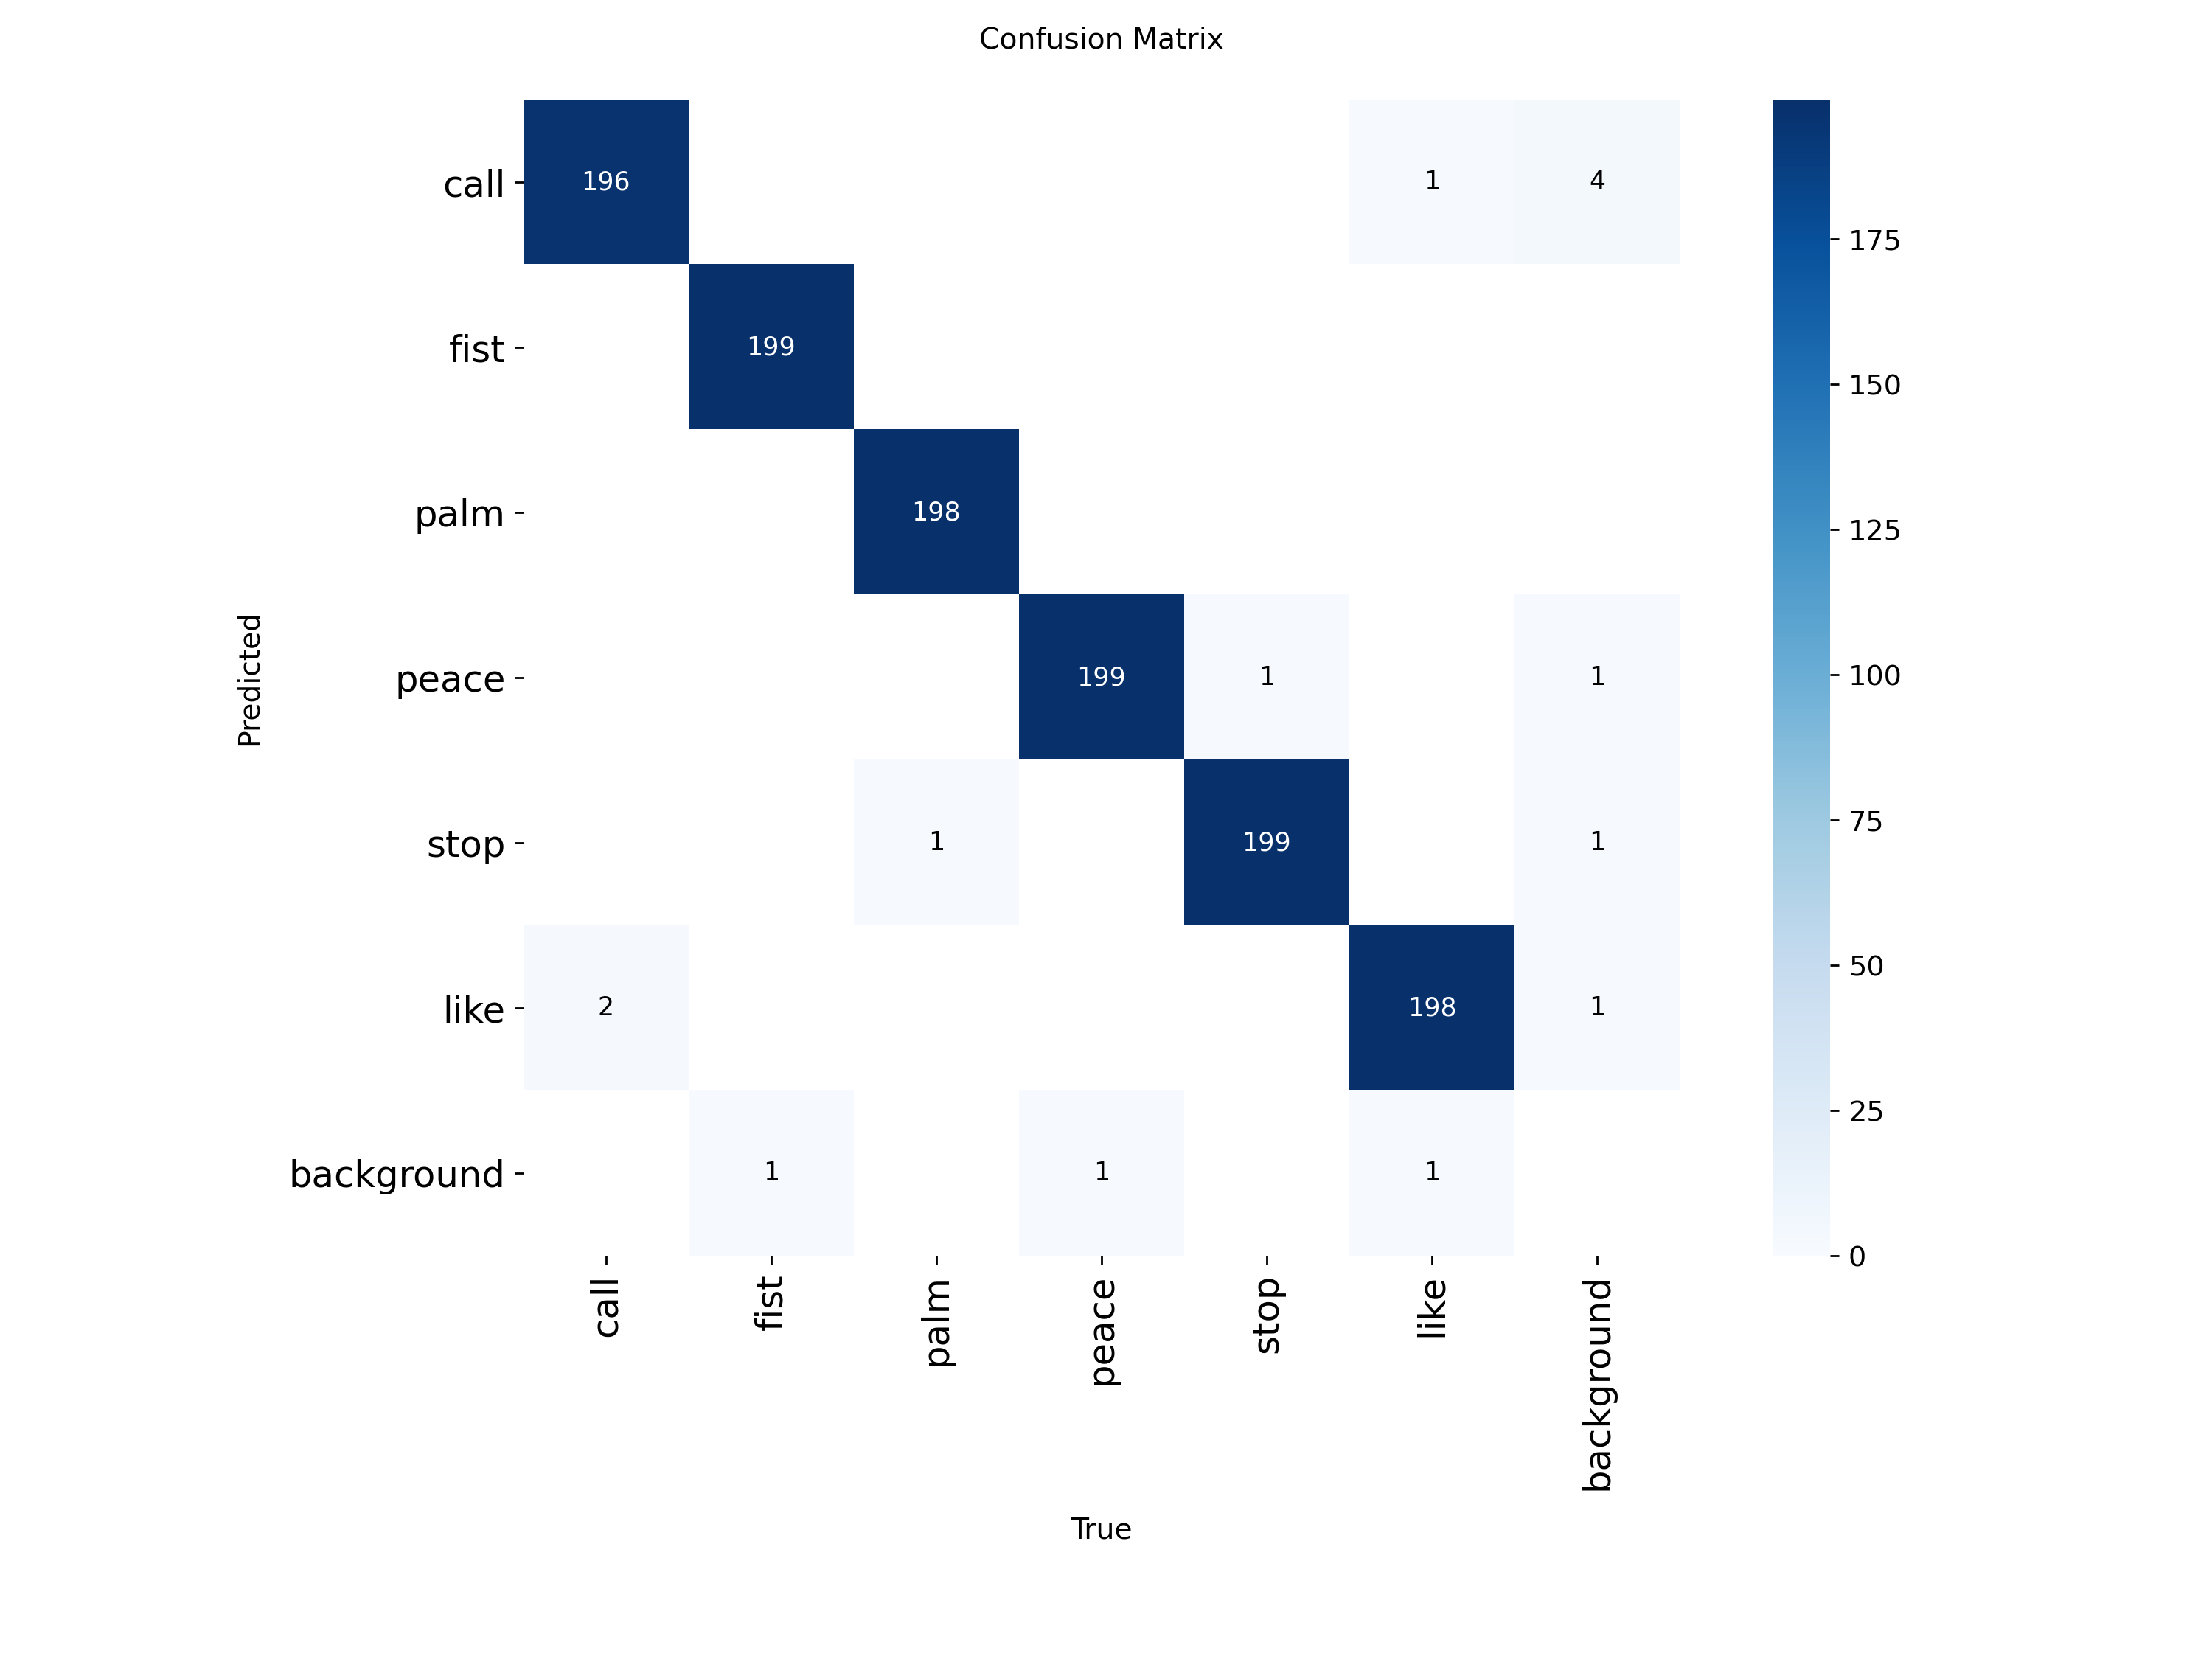

In [11]:
val_dir = BASE_DIR / "runs" / VAL_NAME
cm_png = val_dir / "confusion_matrix.png"
print("Confusion matrix path:", cm_png)

if cm_png.exists():
    display(Image(filename=str(cm_png)))
else:
    print("❌ Không thấy confusion_matrix.png – kiểm tra plots=True & VAL_NAME.")


In [12]:
TEST_NAME = RUN_NAME + "_test"

test_metrics = model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    batch=16,
    plots=True,
    project=str(BASE_DIR / "runs"),
    name=TEST_NAME
)

box_test = test_metrics.box
speed_test = test_metrics.speed

print("=== TEST METRICS ===")
print(f"mAP50-95 (mAP): {box_test.map:.4f}")
print(f"mAP50:          {box_test.map50:.4f}")
print(f"Precision (P):  {box_test.p.mean():.4f}")
print(f"Recall (R):     {box_test.r.mean():.4f}")
print(f"F1-score:       {box_test.f1.mean():.4f}")

inf_ms_test = speed_test['inference']
fps_test = 1000.0 / inf_ms_test
print(f"Inference time: {inf_ms_test:.2f} ms/image  →  FPS ≈ {fps_test:.2f}")


Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 122.5±12.6 MB/s, size: 938.8 KB)
val: Scanning /content/dataset_1000/labels/test... 1200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1200/1200 385.0it/s 3.1s
val: New cache created: /content/dataset_1000/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 75/75 1.7it/s 45.2s
                   all       1200       1200      0.994      0.988      0.993      0.823
                  call        200        200      0.983      0.995      0.992      0.767
                  fist        200        200          1      0.974      0.991      0.759
                  palm        200        200       0.99      0.985      0.995      0.889
                 peace        200        200          1      0.994      0.995      0.844
                  stop        200        200       0.99      0.9

In [13]:
class_names = ["call", "fist", "palm", "peace", "stop", "like"]

print("=== VAL – từng lớp ===")
for i, name in enumerate(class_names):
    print(
        f"{i} - {name:5s} | "
        f"P={box_metrics.p[i]:.3f}  "
        f"R={box_metrics.r[i]:.3f}  "
        f"F1={box_metrics.f1[i]:.3f}  "
        f"mAP50={box_metrics.maps[i]:.3f}"
    )


=== VAL – từng lớp ===
0 - call  | P=0.983  R=0.990  F1=0.986  mAP50=0.768
1 - fist  | P=1.000  R=0.997  F1=0.998  mAP50=0.772
2 - palm  | P=0.998  R=0.995  F1=0.996  mAP50=0.890
3 - peace | P=0.996  R=0.995  F1=0.995  mAP50=0.845
4 - stop  | P=0.994  R=1.000  F1=0.997  mAP50=0.878
5 - like  | P=0.995  R=0.982  F1=0.988  mAP50=0.814


In [14]:
import shutil
from google.colab import files

zip_path = "/content/gesture_v2_L2_all"
shutil.make_archive(zip_path, "zip", RUN_DIR)   # tạo /content/gesture_v2_L2_all.zip

files.download(zip_path + ".zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>